# Graphs for Demand Exercise

NOTE: The scripts below requires python and an installation of the pybalmorel module. This module is very new, so be critical. Feel free to post issues [here](https://github.com/Mathias157/pybalmorel/issues)

**Installation:**

Open a terminal, activate your virtual environment and write:

`pip install pybalmorel`

## Loading Results

In [2]:
!pip install pybalmorel

^C


In [3]:
import pybalmorel 
import matplotlib.pyplot as plt

In [30]:
from pathlib import Path
from pybalmorel import MainResults
from pybalmorel.formatting import balmorel_colours

results_path = Path.cwd() / "0_results_for_python_noDECOM"

print(results_path)

res = MainResults(
    files=["1.gdx", "2.gdx", "3.gdx", "4.gdx", "Base.gdx", "2025.gdx"],
    paths=str(results_path)
)

c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\1.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\2.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\3.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\4.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\Base.gdx
Loading c:\Users\ir8n8\Desktop\DTU3\Large Energy Systems Analysis\Balmorel\LSESAub\0_results_for_python_noDECOM\2025.gdx


## Plotting Objective Function

Index(['Scenario', 'Year', 'Country', 'From', 'To', 'Category', 'Unit',
       'Value'],
      dtype='object')


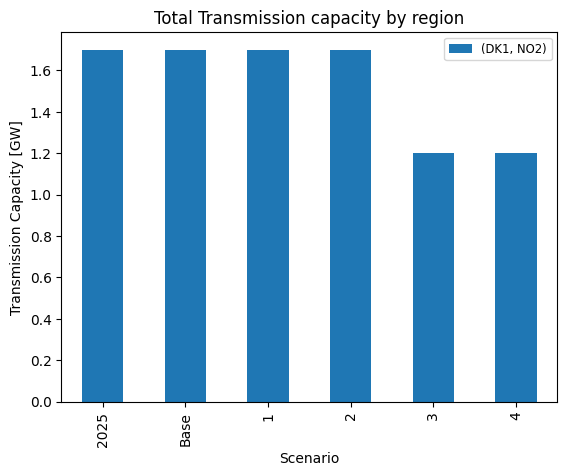

In [31]:
obj_emi = res.get_result('X_CAP_YCR')

# Print columns of obj_emi
print(obj_emi.columns)

# Aggregate
#Show transmission from region to region, I want only NO2 to DK1
obj_emi = obj_emi[(obj_emi['From'] == 'NO2') & (obj_emi['To'] == 'DK1')]
obj_emi = obj_emi.pivot_table(index='Scenario', 
                columns=['To', 'From'],  
                values='Value',
                aggfunc='sum')

# Plot
#order the scenarios
obj_emi = obj_emi.reindex(['2025', 'Base', '1', '2', '3', '4'])

ax = obj_emi.plot(kind='bar', stacked=True, ylabel='Transmission Capacity [GW]', grid=False)
ax.set_title('Total Transmission capacity by region')

# make the legend inside the plot area
ax.legend(
    loc='upper right',
    ncols=2,
    frameon=True,
    fontsize='small'
)


## Capacity Results by Technology


===== DENMARK generation technologies shown =====
['SOLAR-PV', 'CHP-BACK-PRESSURE', 'WIND-ON', 'ELECT-TO-HEAT', 'WIND-OFF', 'BOILERS', 'CONDENSING', 'OTHER']

===== DENMARK storage technologies shown =====
['H2-STORAGE', 'INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'INTRASEASONAL-ELECT-STORAGE']

===== NORWAY generation technologies shown =====
['HYDRO-RESERVOIRS', 'HYDRO-RUN-OF-RIVER', 'WIND-ON', 'BOILERS', 'SOLAR-PV', 'OTHER']

===== NORWAY storage technologies shown =====
['INTERSEASONAL-HEAT-STORAGE', 'INTRASEASONAL-HEAT-STORAGE', 'H2-STORAGE']


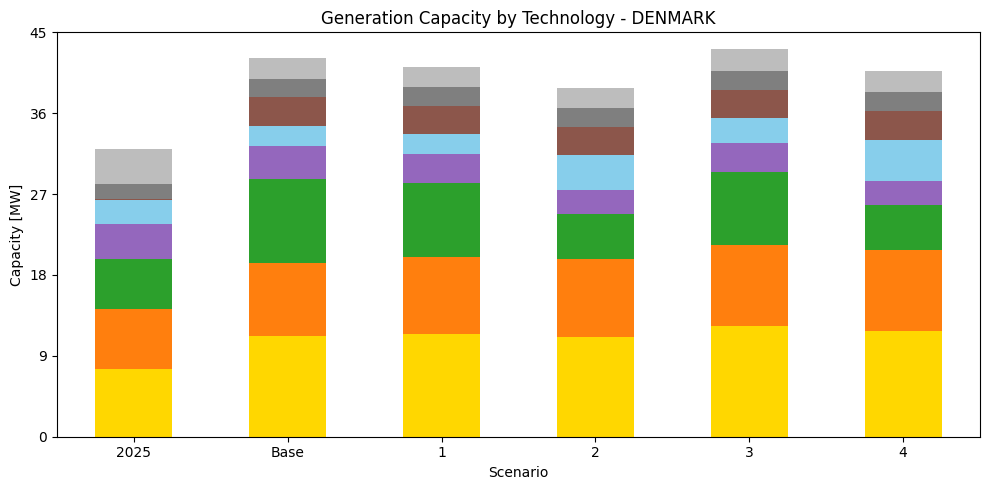

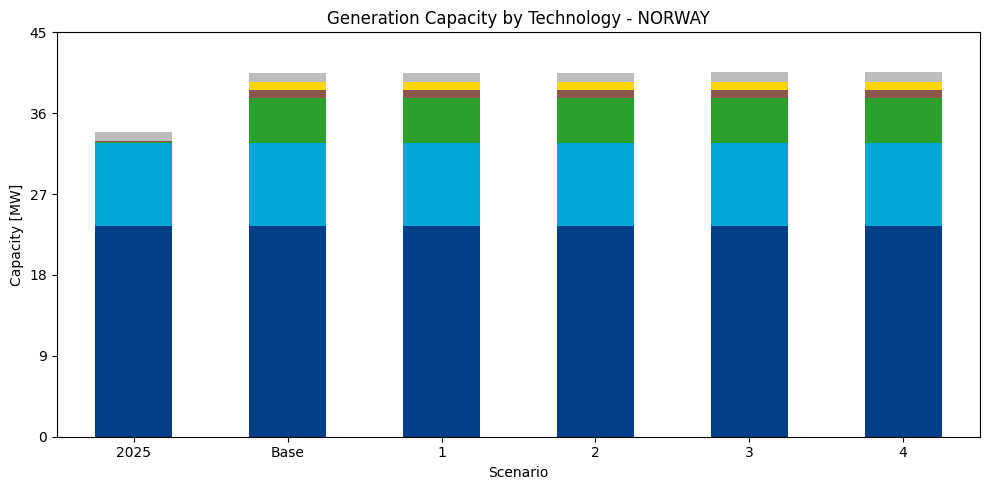

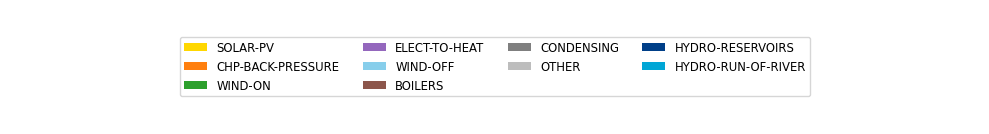

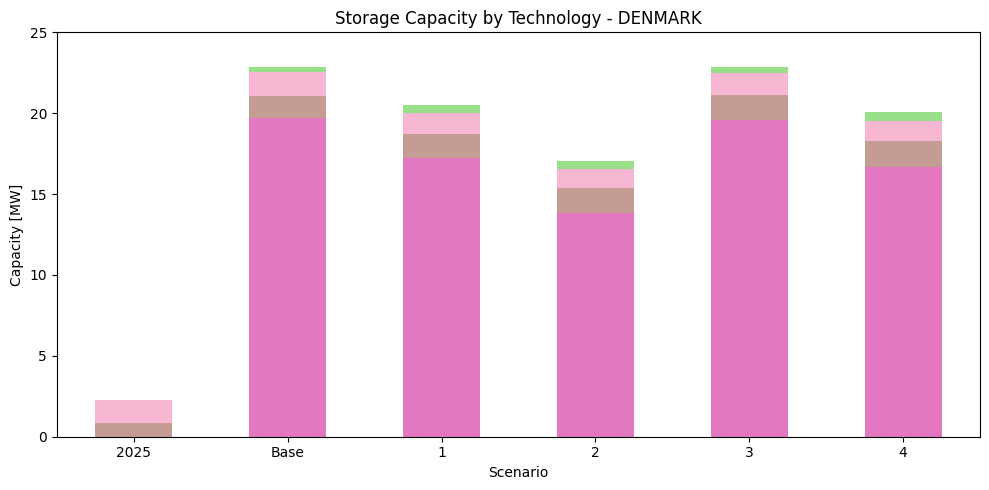

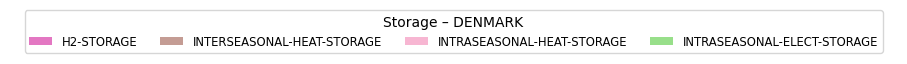

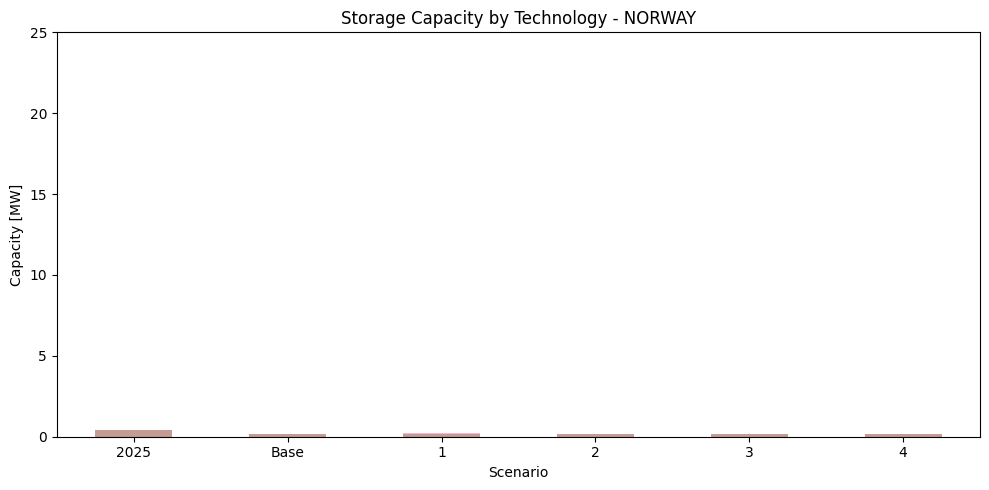

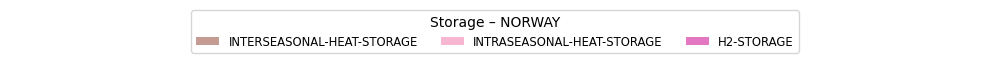

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Retrieve installed capacity results
obj = res.get_result('G_CAP_YCRAF')

# Define scenario order
scenario_order = ['2025', 'Base', '1', '2', '3', '4']

# Countries to analyse
countries = ['DENMARK', 'NORWAY']

# Fixed y-axis scale for all plots
ymax = {
    ('DENMARK', 'Generation'): 45,  
    ('DENMARK', 'Storage'):    25, 
    ('NORWAY',  'Generation'): 45,
    ('NORWAY',  'Storage'):    25,
}

# Storage technologies
storage_techs = {
    'DENMARK': [
        'H2-STORAGE',
        'INTERSEASONAL-HEAT-STORAGE',
        'INTRASEASONAL-ELECT-STORAGE',
        'INTRASEASONAL-HEAT-STORAGE',
    ],
    'NORWAY': [
        'H2-STORAGE',
        'INTERSEASONAL-HEAT-STORAGE',
        'INTRASEASONAL-ELECT-STORAGE',
        'INTRASEASONAL-HEAT-STORAGE',
    ]
}

# Technologies to group into OTHER in the generation plots
generation_other_techs = {
    'DENMARK': [
        'CHP-EXTRACTION',
        'ELECTROLYZER',
        'SOLAR-HEATING',
        'FUELCELL',
        'STEAMREFORMING',
        'HYDRO-RUN-OF-RIVER',
    ],
    'NORWAY': [
        'ELECT-TO-HEAT',
        'ELECTROLYZER',
        'CHP-BACK-PRESSURE',
        'STEAMREFORMING',
    ]
}

# Fixed color for each technology
technology_colors = {
    'SOLAR-PV': '#FFD700',
    'WIND-ON': '#2CA02C',
    'WIND-OFF': '#87CEEB',
    'CHP-BACK-PRESSURE': '#FF7F0E',
    'CHP-EXTRACTION': '#D62728',
    'BOILERS': '#8C564B',
    'CONDENSING': '#7F7F7F',
    'ELECT-TO-HEAT': '#9467BD',
    'ELECTROLYZER': '#1F77B4',
    'FUELCELL': '#AEC7E8',
    'SOLAR-HEATING': '#FFBB78',
    'STEAMREFORMING': '#BCBD22',
    'HYDRO-RESERVOIRS': '#003F88',
    'HYDRO-RUN-OF-RIVER': '#00A6D6',
    'H2-STORAGE': '#E377C2',
    'INTERSEASONAL-HEAT-STORAGE': '#C49C94',
    'INTRASEASONAL-ELECT-STORAGE': '#98DF8A',
    'INTRASEASONAL-HEAT-STORAGE': '#F7B6D2',
    'OTHER': '#BDBDBD',
}

# Keep only Denmark and Norway
obj = obj[obj['Country'].isin(countries)].copy()

# Automatically define generation technologies as all non-storage technologies
generation_techs = {}

for country in countries:
    available_techs = sorted(
        obj[obj['Country'] == country]['Technology'].dropna().unique()
    )
    generation_techs[country] = [
        tech for tech in available_techs
        if tech not in storage_techs[country]
    ]


def prepare_capacity_mix(data, country, tech_list, other_techs=None):
    if other_techs is None:
        other_techs = []

    df = data[data['Country'] == country].copy()

    df = df.pivot_table(
        index='Scenario',
        columns='Technology',
        values='Value',
        aggfunc='sum'
    )

    for tech in tech_list:
        if tech not in df.columns:
            df[tech] = 0

    visible_techs = [
        tech for tech in tech_list
        if tech not in other_techs
    ]

    other_existing = [
        tech for tech in other_techs
        if tech in df.columns
    ]

    if len(other_existing) > 0:
        df['OTHER'] = df[other_existing].sum(axis=1)
        final_cols = visible_techs + ['OTHER']
    else:
        final_cols = visible_techs

    df = df[final_cols]
    df = df.reindex(scenario_order).fillna(0)
    df = df.loc[:, df.sum(axis=0) != 0]

    cols_without_other = [col for col in df.columns if col != 'OTHER']
    sorted_cols = (
        df[cols_without_other]
        .sum(axis=0)
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    if 'OTHER' in df.columns:
        sorted_cols = sorted_cols + ['OTHER']

    df = df[sorted_cols]

    return df


# Prepare generation and storage capacity tables
capacity_generation = {}
capacity_storage = {}

for country in countries:
    capacity_generation[country] = prepare_capacity_mix(
        obj,
        country,
        generation_techs[country],
        other_techs=generation_other_techs[country]
    )
    capacity_storage[country] = prepare_capacity_mix(
        obj,
        country,
        storage_techs[country],
        other_techs=[]
    )

# Print resulting technology groups
for country in countries:
    print(f'\n===== {country} generation technologies shown =====')
    print(capacity_generation[country].columns.tolist())
    print(f'\n===== {country} storage technologies shown =====')
    print(capacity_storage[country].columns.tolist())


def plot_capacity_mix(df, country, group_name, ymax_dict):
    if len(df.columns) == 0:
        print(f'No data to plot for {group_name} - {country}')
        return None

    color_list = [
        technology_colors.get(tech, '#CCCCCC')
        for tech in df.columns
    ]

    ax = df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        ylabel='Capacity [MW]',
        rot=0,
        color=color_list,
        grid=False
    )

    handles, labels = ax.get_legend_handles_labels()

    ymax_plot = ymax_dict[(country.upper(), group_name)]
    ax.set_ylim(0, ymax_plot * 1)
    ax.set_yticks(np.linspace(0, ymax_plot, 6))
    ax.set_title(f'{group_name} Capacity by Technology - {country}')
    ax.legend().remove()

    plt.tight_layout()
    plt.show()

    return handles, labels


def plot_legend(handles, labels, title):
    # Estimate figure width based on number of entries
    ncol = min(4, len(labels))
    nrow = int(np.ceil(len(labels) / ncol))
    fig_height = 0.4 + nrow * 0.35

    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis('off')
    ax.legend(
        handles,
        labels,
        title=title,
        loc='center',
        ncol=ncol,
        frameon=True,
        fontsize='small'
    )
    plt.tight_layout()
    plt.show()


# Plot generation figures and collect one combined legend
generation_handles = {}
generation_labels = {}

for country in countries:
    result = plot_capacity_mix(
        capacity_generation[country],
        country,
        'Generation',
        ymax
    )

    if result is not None:
        handles, labels = result

        for handle, label in zip(handles, labels):
            if label not in generation_labels:
                generation_labels[label] = label
                generation_handles[label] = handle

# Plot one shared legend for Denmark + Norway generation
plot_legend(
    list(generation_handles.values()),
    list(generation_labels.values()),
    title=''
)


# Plot storage figures and keep separate legends
for country in countries:
    result = plot_capacity_mix(
        capacity_storage[country],
        country,
        'Storage',
        ymax
    )

    if result is not None:
        plot_legend(*result, title=f'Storage – {country}')

## Total System Costs

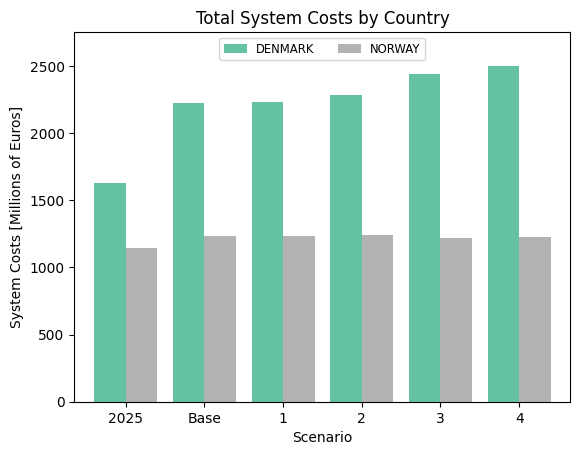

In [33]:
obj = res.get_result('OBJ_YCR')

# Aggregate
obj = obj.pivot_table(index='Scenario', 
                columns=['Country'],  
                values='Value',
                aggfunc='sum')

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap like 'viridis', 'Set2', 'tab10', 'Pastel1', or 'coolwarm'
cmap = plt.colormaps['Set2'] 
num_colors = len(obj.columns)
color_list = [cmap(i / (num_colors - 1)) for i in range(num_colors)]

# Plot using grouped bars instead of stacked bars
ax = obj.plot(kind='bar', stacked=False, ylabel='System Costs [Millions of Euros]', rot=0, 
              color=color_list, width=0.8)
ax.set_title('Total System Costs by Country')

ax.set_ylim(top=ax.get_ylim()[1] * 1.05)

ax.legend(
    loc='upper center',
    ncols=3,
    frameon=True,
    fontsize='small'
)


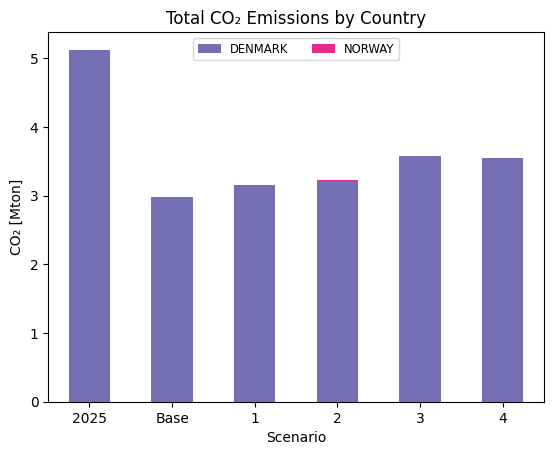

In [34]:
obj = res.get_result('EMI_YCRAG')

# Aggregate
obj = obj.pivot_table(
    index='Scenario',
    columns=['C'],
    values='Value',
    aggfunc='sum'
)

# Convert kTon → Mton
obj = obj / 1000

# Make the order of scenarios correct
obj = obj.reindex(['2025', 'Base', '1', '2', '3', '4'])

# Choose a colormap
# Choose colors from Dark2 starting at the third color
cmap = plt.colormaps['Dark2']
color_list = cmap.colors[2:2 + len(obj.columns)]

# Plot
ax = obj.plot(
    kind='bar',
    stacked=True,
    ylabel='CO₂ [Mton]',
    rot=0,
    color=color_list
)

ax.set_title('Total CO₂ Emissions by Country')

ax.legend(
    loc='upper center',
    ncols=2,
    frameon=True,
    fontsize='small'
)

## Electricity Prices

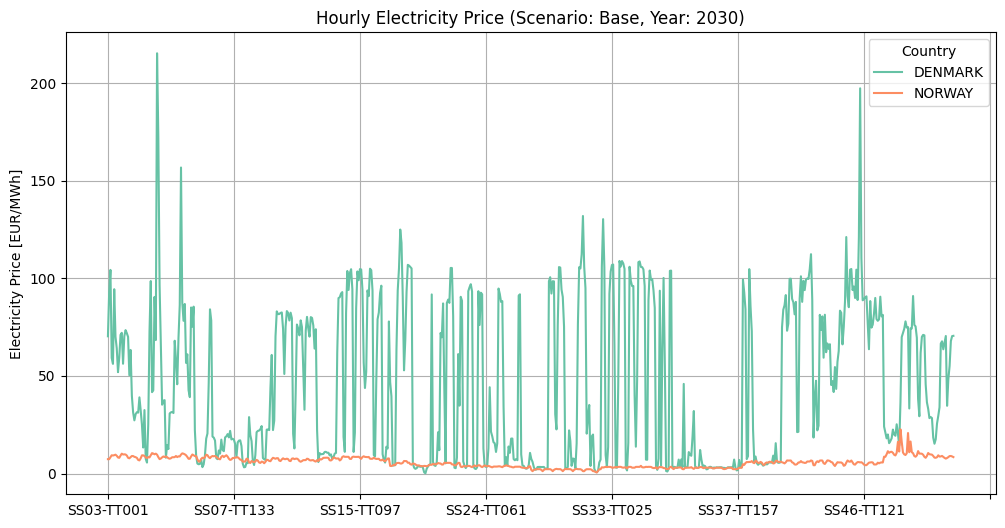

In [35]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# METHOD B: Remove any row where the price is greater than 1000
obj = obj[obj['Value'] <= 300]

# 3. Pivot with Time dimensions as rows, and Countries as columns
hourly_prices = obj.pivot_table(
    index=['Season', 'Time'],  # This preserves the chronological time order
    columns=['Country'],  
    values='Value',
    aggfunc='mean'             # Use mean instead of sum in case of duplicate entries
)

# 4. Optional: Flatten the MultiIndex so pandas can plot it sequentially on the x-axis
hourly_prices.index = [f"S{s}-T{t}" for s, t in hourly_prices.index]

# 5. Plot the profile
cmap = plt.colormaps['Set2']
ax = hourly_prices.plot(kind='line', ylabel='Electricity Price [EUR/MWh]', color=cmap.colors, figsize=(12, 6))
ax.set_title('Hourly Electricity Price (Scenario: Base, Year: 2030)')
plt.grid(True)

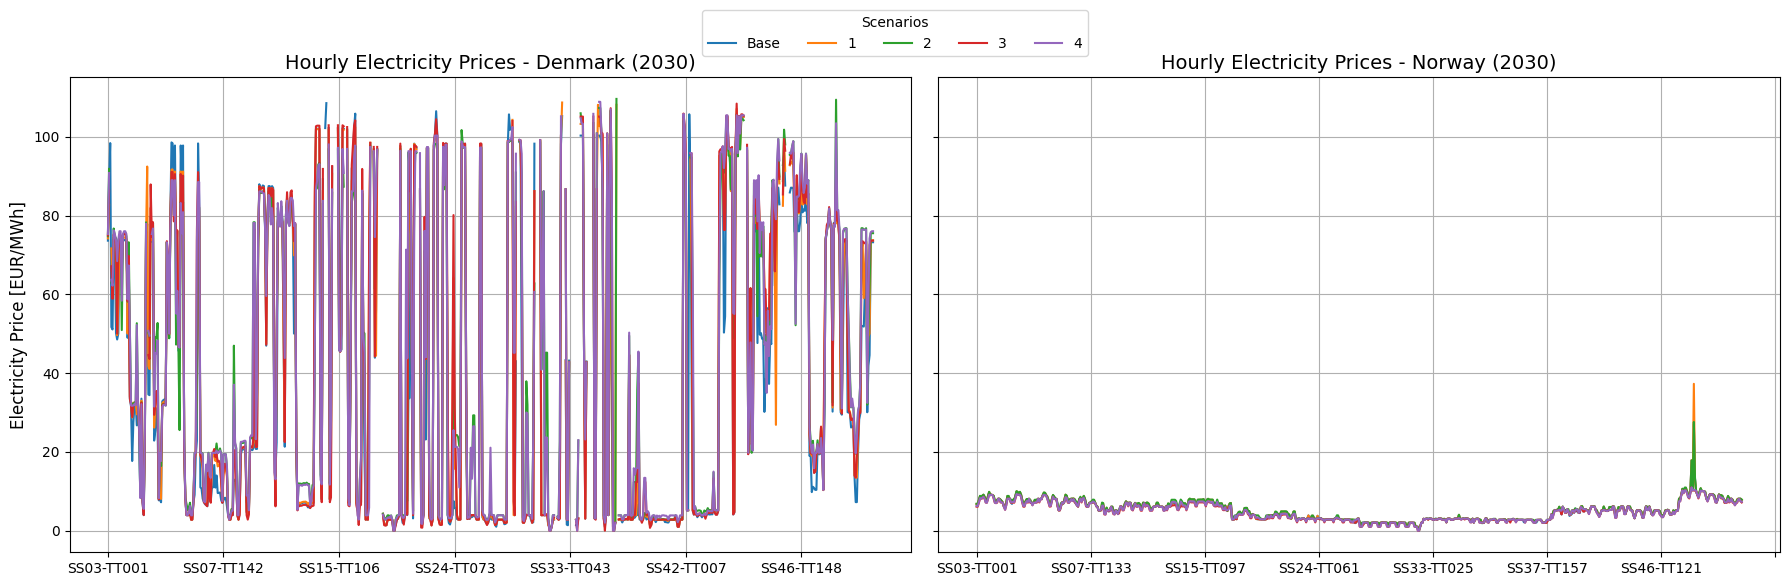

In [36]:
# 1. Pull raw Balmorel GDX results
obj = res.get_result('EL_PRICE_YCRST')

# 2. Basic cleaning: Filter for your target year and clean up extreme price spikes
obj = obj[obj['Value'] <= 110]

# --- Setup the two side-by-side plots ---
fig, (ax_dk, ax_nor) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
cmap = plt.colormaps['tab10']

# Define custom ordered list for scenario lines
scenario_order = ['Base', '1', '2', '3', '4']

# ==========================================
# PLOT 1: DENMARK
# ==========================================
# (Note: Check if your GDX uses 'DENMARK' or 'DK' based on your previous print)
obj_dk = obj[obj['Country'] == 'DENMARK']

prices_dk = obj_dk.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_dk.index = [f"S{s}-T{t}" for s, t in prices_dk.index]

prices_dk.plot(kind='line', ax=ax_dk, color=cmap.colors)
ax_dk.set_title('Hourly Electricity Prices - Denmark (2030)', fontsize=14)
ax_dk.set_ylabel('Electricity Price [EUR/MWh]', fontsize=12)
ax_dk.grid(True)
ax_dk.get_legend().remove() # Remove temporary legend to clean up spacing

# ==========================================
# PLOT 2: NORWAY
# ==========================================
# (Note: Check if your GDX uses 'NORWAY' or 'NO')
obj_nor = obj[obj['Country'] == 'NORWAY']

prices_nor = obj_nor.pivot_table(
    index=['Season', 'Time'], 
    columns=['Scenario'], 
    values='Value', 
    aggfunc='mean'
).reindex(columns=scenario_order)

prices_nor.index = [f"S{s}-T{t}" for s, t in prices_nor.index]

prices_nor.plot(kind='line', ax=ax_nor, color=cmap.colors)
ax_nor.set_title('Hourly Electricity Prices - Norway (2030)', fontsize=14)
ax_nor.grid(True)
ax_nor.get_legend().remove()

# ==========================================
# SHARED LEGEND
# ==========================================
# Place a single clean legend for the scenarios at the top or side
handles, labels = ax_dk.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncols=6, title="Scenarios")

plt.tight_layout(rect=[0, 0, 1, 0.92]) # Make room for the header legend
plt.show()

## Plotting Profiles

(0.0, 42.0)

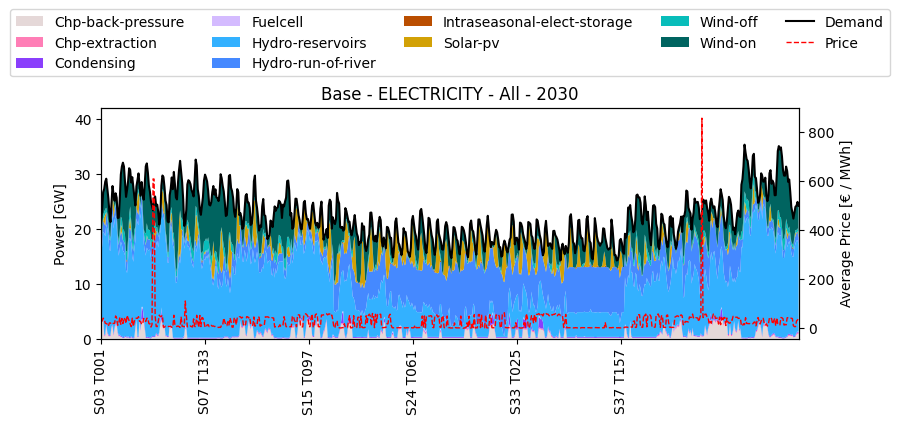

In [37]:
fig, ax = res.plot_profile('Electricity', 2030, scenario='Base')
ax.set_ylim([0, 42])


In [38]:
fig, ax = res.plot_profile('Heat', 2050, scenario='base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netzero')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Heat', 2050, scenario='netnegative')
ax.set_ylim([0, 42])

KeyError: 'base'

## Hydrogen

(0.0, 42.0)

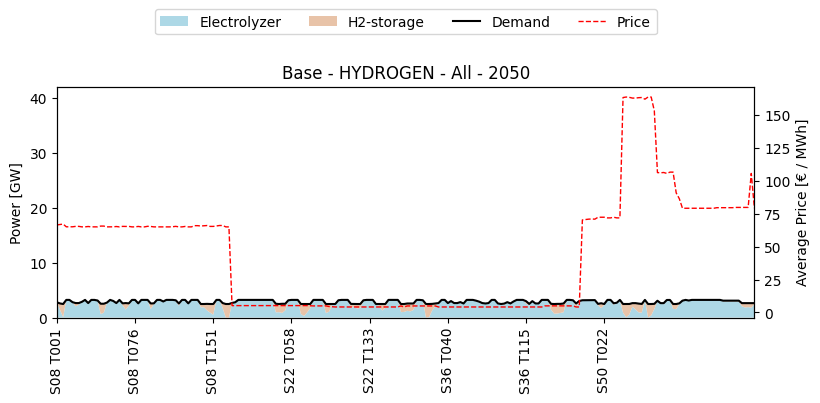

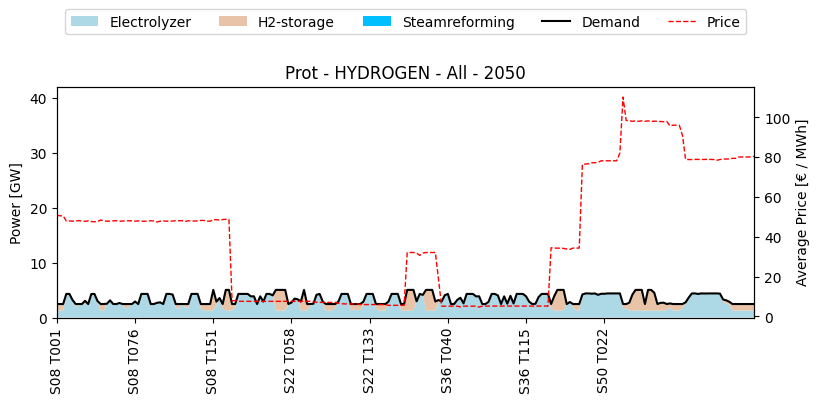

In [ ]:
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Base')
ax.set_ylim([0, 42])
fig, ax = res.plot_profile('Hydrogen', 2050, scenario='Prot')
ax.set_ylim([0, 42])